# Steady-State Error in Unity Feedback Control Systems

In a **unity feedback** system the plant $G(s)$ is driven by the difference between
the reference $R(s)$ and the output $Y(s)$:

$$E(s) = R(s) - Y(s), \qquad T(s) = \frac{G(s)}{1+G(s)}, \qquad \frac{E(s)}{R(s)} = \frac{1}{1+G(s)}$$

The **steady-state error** is the residual as $t\!\to\!\infty$.
Applying the **Final Value Theorem** (requires closed-loop stability):

$$\boxed{e_{ss} = \lim_{s \to 0}\, s\,E(s) = \lim_{s \to 0} \frac{s\,R(s)}{1+G(s)}}$$

## Error constants

Three limits of $G(s)$ summarise its tracking capability:

| Constant | Definition | Governs |
|---|---|---|
| Position $K_p$ | $\displaystyle\lim_{s\to 0} G(s)$ | Step tracking |
| Velocity $K_v$ | $\displaystyle\lim_{s\to 0} s\,G(s)$ | Ramp tracking |
| Acceleration $K_a$ | $\displaystyle\lim_{s\to 0} s^2 G(s)$ | Parabola tracking |

## System type

The **type number** $N$ counts the open-loop poles at $s = 0$:

$$G(s) = \frac{K\,(\cdots)}{s^{\,N}(\cdots)}, \quad N = 0,\,1,\,2,\,\ldots$$

Higher $N$ reduces $e_{ss}$ for a given input class, but each integrator
adds $90^\circ$ of phase lag — stability requires careful design.

## Quick-reference table

| Input | $R(s)$ | Type 0 | Type 1 | Type 2 |
|---|---|---|---|---|
| Step | $R_0/s$ | $R_0/(1+K_p)$ | $0$ | $0$ |
| Ramp | $R_0/s^2$ | $\infty$ | $R_0/K_v$ | $0$ |
| Parabola | $R_0/s^3$ | $\infty$ | $\infty$ | $R_0/K_a$ |


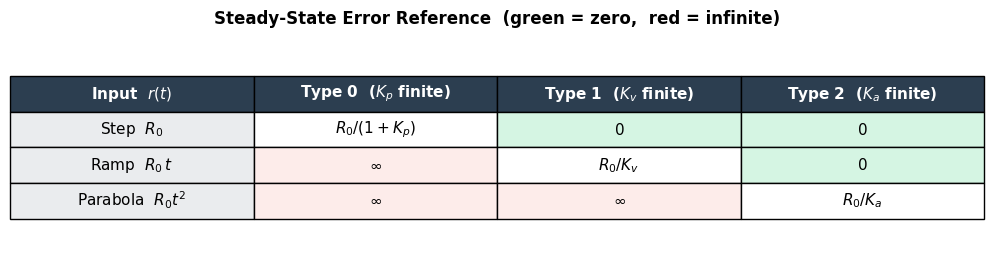

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.signal import lti, lsim
from ipywidgets import interact, widgets

plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

def closed_loop(G_num, G_den):
    # Closed-loop TF:  T = G/(1+G)  where G = G_num/G_den
    # Returns (cl_num, cl_den) as numpy arrays, leading zeros stripped.
    n = max(len(G_num), len(G_den))
    num = np.zeros(n);  num[n - len(G_num):] = G_num
    den = np.zeros(n);  den[n - len(G_den):] = G_den
    cl_num = num.copy()
    cl_den = den + num
    fz = np.argmax(np.abs(cl_num) > 1e-12)  # first non-zero coefficient
    return cl_num[fz:], cl_den

def sim(G_num, G_den, u, t):
    # Simulate unity-feedback closed-loop response to input u.
    cl_num, cl_den = closed_loop(G_num, G_den)
    _, y, _ = lsim(lti(cl_num, cl_den), u, t)
    return y

def ess_arrow(ax, t, ess, r_end, color='purple'):
    # Annotate a finite steady-state error with a double-headed arrow.
    x = t[-1] * 0.90
    ax.annotate('', xy=(x, r_end), xytext=(x, r_end - ess),
                arrowprops=dict(arrowstyle='<->', color=color, lw=2))
    ax.text(x * 1.01, r_end - ess / 2,
            f' $e_{{ss}}$={ess:.3f}', color=color, va='center', fontsize=10)


# Colour-coded steady-state error reference table

fig, ax = plt.subplots(figsize=(10, 2.8))
ax.axis('off')
col_labels = ['Input  $r(t)$', 'Type 0  ($K_p$ finite)',
              'Type 1  ($K_v$ finite)', 'Type 2  ($K_a$ finite)']
rows = [
    ['Step  $R_0$',         '$R_0/(1+K_p)$', '$0$',       '$0$'],
    ['Ramp  $R_0\\,t$',   '$\\infty$',    '$R_0/K_v$', '$0$'],
    ['Parabola  $R_0 t^2$', '$\\infty$',    '$\\infty$', '$R_0/K_a$'],
]
tbl = ax.table(cellText=rows, colLabels=col_labels, cellLoc='center', loc='center')
tbl.auto_set_font_size(False);  tbl.set_fontsize(11);  tbl.scale(1.2, 2.1)

for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50');  cell.set_text_props(color='white', fontweight='bold')
    elif c == 0:
        cell.set_facecolor('#eaecee')
    else:
        val = rows[r-1][c]
        if val == '$0$':
            cell.set_facecolor('#d5f5e3')
        elif val in ('$\\infty$',):
            cell.set_facecolor('#fdecea')

ax.set_title('Steady-State Error Reference  (green = zero,  red = infinite)',
             fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()


## Type 0 — $G(s) = K_p\,/\,(\tau s + 1)$

No pole at the origin. Evaluating the error constants:

$$K_p = \lim_{s\to 0} G(s) = K_p \qquad K_v = \lim_{s\to 0} s\,G(s) = 0 \qquad K_a = 0$$

Applying the FVT to each standard input:

$$e_{ss}^{\text{step}} = \frac{R_0}{1+K_p} \qquad e_{ss}^{\text{ramp}} = \infty \qquad e_{ss}^{\text{parabola}} = \infty$$

Increasing $K_p$ shrinks $e_{ss}^{\text{step}}$ but never eliminates it — a finite offset always remains.
For ramp and parabola inputs the output cannot keep pace and the error grows without bound.


In [ ]:
def plot_type0(Kp=5.0, R0=1.0, Input='Step'):
    tau = 0.5
    t_max = {'Step': 14, 'Ramp': 12, 'Parabola': 5}[Input]
    t = np.linspace(0, t_max, 1400)

    if Input == 'Step':
        u   = R0 * np.ones_like(t)
        ess = R0 / (1.0 + Kp)
        ess_str = f'$R_0/(1+K_p) = {ess:.3f}$'
    elif Input == 'Ramp':
        u   = R0 * t
        ess = np.inf
        ess_str = 'inf  (no integrator in G)'
    else:
        u   = (R0 / 2) * t ** 2
        ess = np.inf
        ess_str = 'inf  (no integrator in G)'

    y = sim([Kp], [tau, 1.0], u, t)
    e = u - y

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

    ax1.plot(t, u, 'C0', lw=2, label='$r(t)$ reference')
    ax1.plot(t, y, 'C1', lw=2, label='$y(t)$ response')
    if np.isfinite(ess):
        ess_arrow(ax1, t, ess, R0)
    ax1.set(xlabel='Time (s)', ylabel='Amplitude',
            title=f'Type 0  |  Kp={Kp:.1f}/(tau s+1),  {Input} input')
    ax1.legend(loc='lower right');  ax1.grid(True, alpha=0.3)

    ax2.plot(t, e, 'C3', lw=2, label='$e(t) = r(t)-y(t)$')
    ax2.axhline(0, color='k', lw=0.8, ls='--')
    if np.isfinite(ess):
        ax2.axhline(ess, color='purple', lw=1.5, ls='--', label=f'ess = {ess:.3f}')
        ax2.set_ylim(-0.05 * R0, ess * 2.5)
    ax2.set(xlabel='Time (s)', ylabel='Error',
            title=f'Error signal — ess = {ess_str}')
    ax2.legend();  ax2.grid(True, alpha=0.3)

    plt.tight_layout();  plt.show()

interact(plot_type0,
    Kp=widgets.FloatSlider(value=5.0, min=0.5, max=20.0, step=0.5,
                           description='Kp', style={'description_width': '60px'}),
    R0=widgets.FloatSlider(value=1.0, min=0.5, max=5.0, step=0.5,
                           description='R0', style={'description_width': '60px'}),
    Input=widgets.RadioButtons(options=['Step', 'Ramp', 'Parabola'],
                               description='Input:', style={'description_width': '60px'})
);


interactive(children=(FloatSlider(value=5.0, description='Kp', max=20.0, min=0.5, step=0.5, style=SliderStyle(…

## Type 1 — $G(s) = K_v\,/\,\bigl[s\,(\tau s + 1)\bigr]$

One integrator drives the position error to zero automatically:

$$K_p = \infty \qquad K_v = \lim_{s\to 0} s\,G(s) = K_v \qquad K_a = 0$$

$$e_{ss}^{\text{step}} = 0 \qquad e_{ss}^{\text{ramp}} = \frac{R_0}{K_v} \qquad e_{ss}^{\text{parabola}} = \infty$$

For a **ramp** the output settles into a trajectory **parallel** to $r(t)$,
displaced by the constant lag $R_0/K_v$.
Larger $K_v$ reduces this lag; however, high open-loop gain narrows the
stability margins and may cause ringing or instability.


In [3]:
def plot_type1(Kv=5.0, R0=1.0, Input='Step'):
    tau = 0.5
    t_max = {'Step': 14, 'Ramp': 12, 'Parabola': 5}[Input]
    t = np.linspace(0, t_max, 1400)

    if Input == 'Step':
        u   = R0 * np.ones_like(t)
        ess = 0.0
        ess_str = '0  (integrator eliminates step error)'
    elif Input == 'Ramp':
        u   = R0 * t
        ess = R0 / Kv
        ess_str = f'R0/Kv = {ess:.3f}  (constant lag)'
    else:
        u   = (R0 / 2) * t ** 2
        ess = np.inf
        ess_str = 'inf  (one integrator is not enough)'

    y = sim([Kv], [tau, 1.0, 0.0], u, t)
    e = u - y

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

    ax1.plot(t, u, 'C0', lw=2, label='$r(t)$ reference')
    ax1.plot(t, y, 'C1', lw=2, label='$y(t)$ response')
    if np.isfinite(ess) and ess > 1e-6:
        ess_arrow(ax1, t, ess, u[-1])
    ax1.set(xlabel='Time (s)', ylabel='Amplitude',
            title=f'Type 1  |  Kv={Kv:.1f}/[s(tau s+1)],  {Input} input')
    ax1.legend(loc='lower right' if Input != 'Step' else 'center right')
    ax1.grid(True, alpha=0.3)

    ax2.plot(t, e, 'C3', lw=2, label='$e(t)$')
    ax2.axhline(0, color='k', lw=0.8, ls='--')
    if np.isfinite(ess) and ess > 1e-6:
        ax2.axhline(ess, color='purple', lw=1.5, ls='--', label=f'ess = {ess:.3f}')
        ax2.set_ylim(-0.1 * ess, ess * 2.8)
    ax2.set(xlabel='Time (s)', ylabel='Error',
            title=f'Error signal — ess = {ess_str}')
    ax2.legend();  ax2.grid(True, alpha=0.3)

    plt.tight_layout();  plt.show()

interact(plot_type1,
    Kv=widgets.FloatSlider(value=5.0, min=0.5, max=20.0, step=0.5,
                           description='Kv', style={'description_width': '60px'}),
    R0=widgets.FloatSlider(value=1.0, min=0.5, max=5.0, step=0.5,
                           description='R0', style={'description_width': '60px'}),
    Input=widgets.RadioButtons(options=['Step', 'Ramp', 'Parabola'],
                               description='Input:', style={'description_width': '60px'})
);


interactive(children=(FloatSlider(value=5.0, description='Kv', max=20.0, min=0.5, step=0.5, style=SliderStyle(…

## Type 2 — $G(s) = K_a\,(\tau s + 1)\,/\,s^2$

Two integrators eliminate both position and velocity errors:

$$K_p = \infty \qquad K_v = \infty \qquad K_a = \lim_{s\to 0} s^2 G(s) = K_a$$

$$e_{ss}^{\text{step}} = 0 \qquad e_{ss}^{\text{ramp}} = 0 \qquad e_{ss}^{\text{parabola}} = \frac{R_0}{K_a}$$

The zero $(\tau s+1)$ in the numerator is **not optional** — it injects phase lead
that stabilises the double integrator in closed loop.
Without it the closed-loop poles are purely imaginary and the step response oscillates forever.
Observe how $K_a$ simultaneously controls the parabolic lag and the transient overshoot.


In [4]:
def plot_type2(Ka=5.0, R0=1.0, Input='Step'):
    tau = 0.5
    t_max = {'Step': 14, 'Ramp': 12, 'Parabola': 6}[Input]
    t = np.linspace(0, t_max, 1400)

    if Input == 'Step':
        u   = R0 * np.ones_like(t)
        ess = 0.0
        ess_str = '0  (two integrators eliminate step error)'
    elif Input == 'Ramp':
        u   = R0 * t
        ess = 0.0
        ess_str = '0  (two integrators eliminate ramp error)'
    else:
        u   = (R0 / 2) * t ** 2
        ess = R0 / Ka
        ess_str = f'R0/Ka = {ess:.3f}  (constant acceleration lag)'

    y = sim([Ka * tau, Ka], [1.0, 0.0, 0.0], u, t)
    e = u - y

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

    ax1.plot(t, u, 'C0', lw=2, label='$r(t)$ reference')
    ax1.plot(t, y, 'C1', lw=2, label='$y(t)$ response')
    if np.isfinite(ess) and ess > 1e-6:
        ess_arrow(ax1, t, ess, u[-1])
    ax1.set(xlabel='Time (s)', ylabel='Amplitude',
            title=f'Type 2  |  Ka={Ka:.1f}(tau s+1)/s^2,  {Input} input')
    ax1.legend(loc='lower right' if Input != 'Step' else 'center right')
    ax1.grid(True, alpha=0.3)

    ax2.plot(t, e, 'C3', lw=2, label='$e(t)$')
    ax2.axhline(0, color='k', lw=0.8, ls='--')
    if np.isfinite(ess) and ess > 1e-6:
        ax2.axhline(ess, color='purple', lw=1.5, ls='--', label=f'ess = {ess:.3f}')
        ax2.set_ylim(-0.1 * ess, ess * 3.0)
    ax2.set(xlabel='Time (s)', ylabel='Error',
            title=f'Error signal — ess = {ess_str}')
    ax2.legend();  ax2.grid(True, alpha=0.3)

    plt.tight_layout();  plt.show()

interact(plot_type2,
    Ka=widgets.FloatSlider(value=5.0, min=0.5, max=20.0, step=0.5,
                           description='Ka', style={'description_width': '60px'}),
    R0=widgets.FloatSlider(value=1.0, min=0.5, max=5.0, step=0.5,
                           description='R0', style={'description_width': '60px'}),
    Input=widgets.RadioButtons(options=['Step', 'Ramp', 'Parabola'],
                               description='Input:', style={'description_width': '60px'})
);


interactive(children=(FloatSlider(value=5.0, description='Ka', max=20.0, min=0.5, step=0.5, style=SliderStyle(…

In [ ]:
# Cross-type comparison: same gain K applied to all three system types.
# Left panel  -- overlaid time responses.
# Right panel -- bar chart of e_ss (green=zero, orange=finite, red=infinite).

def plot_comparison(K=5.0, R0=1.0, Input='Step'):
    tau = 0.5
    t_max = {'Step': 14, 'Ramp': 12, 'Parabola': 6}[Input]
    t = np.linspace(0, t_max, 1400)

    if Input == 'Step':
        u        = R0 * np.ones_like(t)
        ess_vals = [R0 / (1.0 + K), 0.0, 0.0]
        ess_lbl  = [f'{R0/(1+K):.3f}', '0', '0']
    elif Input == 'Ramp':
        u        = R0 * t
        ess_vals = [np.inf, R0 / K, 0.0]
        ess_lbl  = ['inf', f'{R0/K:.3f}', '0']
    else:
        u        = (R0 / 2) * t ** 2
        ess_vals = [np.inf, np.inf, R0 / K]
        ess_lbl  = ['inf', 'inf', f'{R0/K:.3f}']

    y0 = sim([K],         [tau, 1.0],       u, t)  # Type 0
    y1 = sim([K],         [tau, 1.0, 0.0],  u, t)  # Type 1
    y2 = sim([K*tau, K],  [1.0, 0.0, 0.0],  u, t)  # Type 2

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

    ax1.plot(t, u,  'k--', lw=1.5, alpha=0.6, label='r(t)')
    ax1.plot(t, y0, 'C0',  lw=2,              label='Type 0')
    ax1.plot(t, y1, 'C1',  lw=2,              label='Type 1')
    ax1.plot(t, y2, 'C2',  lw=2,              label='Type 2')
    ax1.set(xlabel='Time (s)', ylabel='Amplitude',
            title=f'All types  |  {Input} input  (K={K},  R0={R0})')
    ax1.legend();  ax1.grid(True, alpha=0.3)

    bar_h   = [v if np.isfinite(v) else 20.0 for v in ess_vals]
    colours = ['#e74c3c' if np.isinf(v) else
               ('#2ecc71' if v < 1e-9 else '#f39c12') for v in ess_vals]
    bars = ax2.bar(['Type 0', 'Type 1', 'Type 2'], bar_h,
                   color=colours, edgecolor='k', linewidth=0.8, width=0.5)

    for bar, lbl, val in zip(bars, ess_lbl, ess_vals):
        cx = bar.get_x() + bar.get_width() / 2
        ax2.text(cx, bar.get_height() + 0.35, lbl,
                 ha='center', va='bottom', fontweight='bold', fontsize=12)
        if np.isinf(val):
            ax2.text(cx, bar.get_height() * 0.42, 'inf',
                     ha='center', color='white', fontweight='bold', fontsize=12)

    patches = [mpatches.Patch(color='#2ecc71', label='Zero'),
               mpatches.Patch(color='#f39c12', label='Finite'),
               mpatches.Patch(color='#e74c3c', label='Infinite (shown as 20)')]
    ax2.legend(handles=patches, loc='upper right', fontsize=9)
    ax2.set(xlabel='System Type', ylabel='e_ss', ylim=(0, 24),
            title=f'Steady-state error  |  {Input} input')
    ax2.grid(True, axis='y', alpha=0.3)

    plt.tight_layout();  plt.show()

interact(plot_comparison,
    K=widgets.FloatSlider(value=5.0, min=0.5, max=20.0, step=0.5,
                          description='Gain K', style={'description_width': '80px'}),
    R0=widgets.FloatSlider(value=1.0, min=0.5, max=5.0, step=0.5,
                           description='R0',    style={'description_width': '80px'}),
    Input=widgets.RadioButtons(options=['Step', 'Ramp', 'Parabola'],
                               description='Input:', style={'description_width': '80px'})
);


interactive(children=(FloatSlider(value=5.0, description='Gain K', max=20.0, min=0.5, step=0.5, style=SliderSt…